#  Linear Regression

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


#### Data Loading

In [21]:
df=pd.read_csv("housing_data_yemen.csv")

#### Displaying a Sample of the Data

In [22]:
df.head()

,Area,Rooms,Age,City,Floors,Material,Price
0,9.0,6.0,29,Sanaa,3,Block,64920000.0
1,13.0,5.0,24,Dhamar,1,Block,NaN
2,14.0,7.0,38,Ibb,2,stone,66220000.0
3,14.0,6.0,49,Sanaa,3,Block,68520000.0
4,17.0,8.0,44,Sanaa,3,Block,77520000.0


#### Data Information

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Area      94 non-null     float64
 1   Rooms     96 non-null     float64
 2   Age       100 non-null    int64  
 3   City      100 non-null    object 
 4   Floors    100 non-null    int64  
 5   Material  100 non-null    object 
 6   Price     91 non-null     float64
dtypes: float64(3), int64(2), object(2)
memory usage: 5.6+ KB


#### Statistical Description

In [24]:
df.describe()

,Area,Rooms,Age,Floors,Price
count,94.00000,96.000000,100.000000,100.000000,9.100000e+01
mean,15.37234,5.489583,25.500000,1.920000,6.766110e+07
std,8.09086,1.414175,15.276244,0.872475,5.201188e+07
min,3.00000,3.000000,1.000000,1.000000,3.456000e+07
25%,8.00000,4.000000,10.750000,1.000000,5.140000e+07
50%,14.50000,5.000000,26.500000,2.000000,5.880000e+07
75%,21.00000,6.000000,38.250000,3.000000,6.897500e+07
max,30.00000,8.000000,50.000000,3.000000,4.590000e+08


#### Displaying the Data

<function matplotlib.pyplot.show(close=None, block=None)>

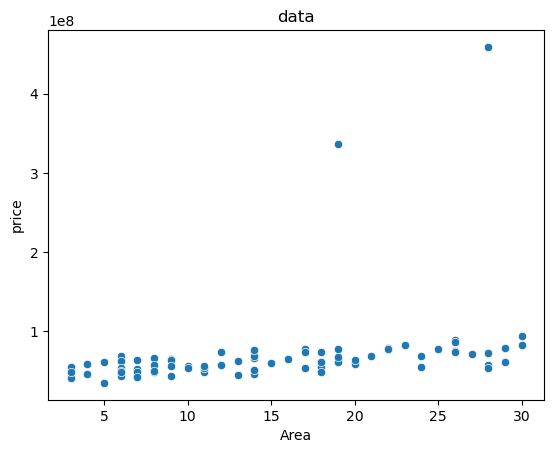

In [25]:
sns.scatterplot(x=df['Area'],y=df['Price'])
plt.title("data")
plt.xlabel("Area")
plt.ylabel("price")
plt.show

#### Removing Outliers

In [26]:
df=df[df['Price']<200000000]

#### Displaying the Data After Removing Outliers

<function matplotlib.pyplot.show(close=None, block=None)>

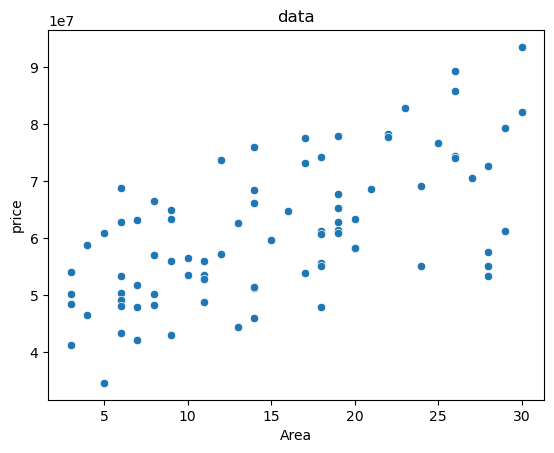

In [27]:
sns.scatterplot(x=df['Area'],y=df['Price'])
plt.title("data")
plt.xlabel("Area")
plt.ylabel("price")
plt.show

#### Displaying Null Values


In [28]:
df.isnull().sum()

Area        5
Rooms       4
Age         0
City        0
Floors      0
Material    0
Price       0
dtype: int64

#### Filling Values

In [ ]:
df['Area'].fillna(df['Area'].median(),inplace=True)

0      9.0
2     14.0
3     14.0
4     17.0
5     11.0
      ... 
94    26.0
95    29.0
97    27.0
98     6.0
99    10.0
Name: Area, Length: 89, dtype: float64

In [32]:
df.isnull().sum()

Area        0
Rooms       4
Age         0
City        0
Floors      0
Material    0
Price       0
dtype: int64

#### Independent and Dependent Variables


In [34]:
X=df[['Area']]
Y=df['Price']

#### Data Splitting

In [35]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

#### Building the Model


In [36]:
model=LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


#### Displaying the Equation


In [37]:
a=model.coef_
b=model.intercept_
print(f"price =Area * {a[0]}+{b}")

price =Area * 1025726.6720261769+44968357.66268934


#### Predicting Test Values


In [38]:
yhat=model.predict(x_test)

#### Performance Evaluation


In [41]:
mse=mean_squared_error(y_test,yhat)
rmse=np.sqrt(mse)
mean=np.mean(yhat)
error=(rmse/mean)*100
print({f"the Error={error}"})

{'the Error=16.51458813131408'}


#### Displaying the Data with the Best Fit Line


c:\Users\Raidan\anaconda3\envs\IPPR\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


<function matplotlib.pyplot.show(close=None, block=None)>

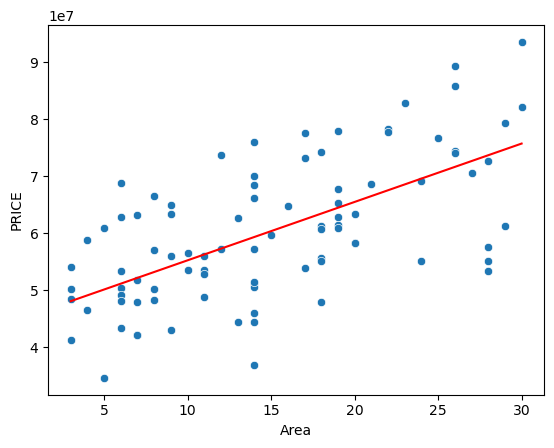

In [45]:
sns.scatterplot(x=df['Area'],y=df['Price'])
input_value=np.linspace(df['Area'].min(),df['Area'].max(),100).reshape(100,1)
output_value=model.predict(input_value)
plt.plot(input_value,output_value,color='red')
plt.xlabel("Area")
plt.ylabel("PRICE")
plt.show